**Часть 1. EDA**

**Данные с Kaggle по ценам на жильё в Airbnb в Нью-Йорке заранее скачаны в локальную директорию ./homework_10/data/AB_NYC_2019.csv**

1.1 Основные шаги работы с данными


In [27]:
#Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
#Читаем файл с данными, смотрим размерность и структуру данных
data = pd.read_csv('data/AB_NYC_2019.csv')
print('Размерность датасета:', data.shape)
data.head()

Размерность датасета: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
#Удаляем ненужные признаки
data = data.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
print('Размерность после удаления признаков:', data.shape)
data.head()

Размерность после удаления признаков: (48895, 11)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [4]:
#Анализ типов признаков
print(data.dtypes)

neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [5]:
#Смотрим описание признаков
#Сам датасет не собержит метаданных по описанию значений признаков. Попробуем найти (или предположить описание по значениям в столбце)
# Нашли источник https://insideairbnb.com ->  https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1343655814#gid=1343655814
# Data Dictionary for listings.csv summary file
# *Перевод на русский язык любительский без претензии на официальные значения.

# neighbourhood_group   Округ = административный район = группа районов (The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles)
# neighbourhood	        Район внутри округа (The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.)
# latitude              Широта (Uses the World Geodetic System (WGS84) projection for latitude and longitude.)
# longitude	            Долгота (Uses the World Geodetic System (WGS84) projection for latitude and longitude.)
# room_type	            Тип жилья: Entire home\apt / Private room & etc.
# price	                Цена за сутки, $ (daily price in local currency. Note, $ sign may be used despite locale)
# minimum_nights	    Минимальное количество ночей для размещения  (хозяин устанавливает сам?) (minimum number of night stay for the listing (calendar rules may be different))
# number_of_reviews	    Общее количество отзывов (The number of reviews the listing has)
# reviews_per_month     Количество отзывов в месяц (среднее? возможно, показатель популярности)
# calculated_host_listings_count	Количество объявлений, которые хозяин имеет в текущем поиске, в географическом районе города/региона (The number of listings the host has in the current scrape, in the city/region geography.)
# availability_365	Доступность объявления через Х дней в будущем, определяемая календарем (avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host.)


**Целевая переменная** `price` (Цена за сутки, $). Это то, что мы будем предсказывать.

In [6]:
#Базовая статистика
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
#Пропущенные значения
print(data.isnull().sum())

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


видим, что с reviews_per_month многова-то пропусков... посмотрим далее.

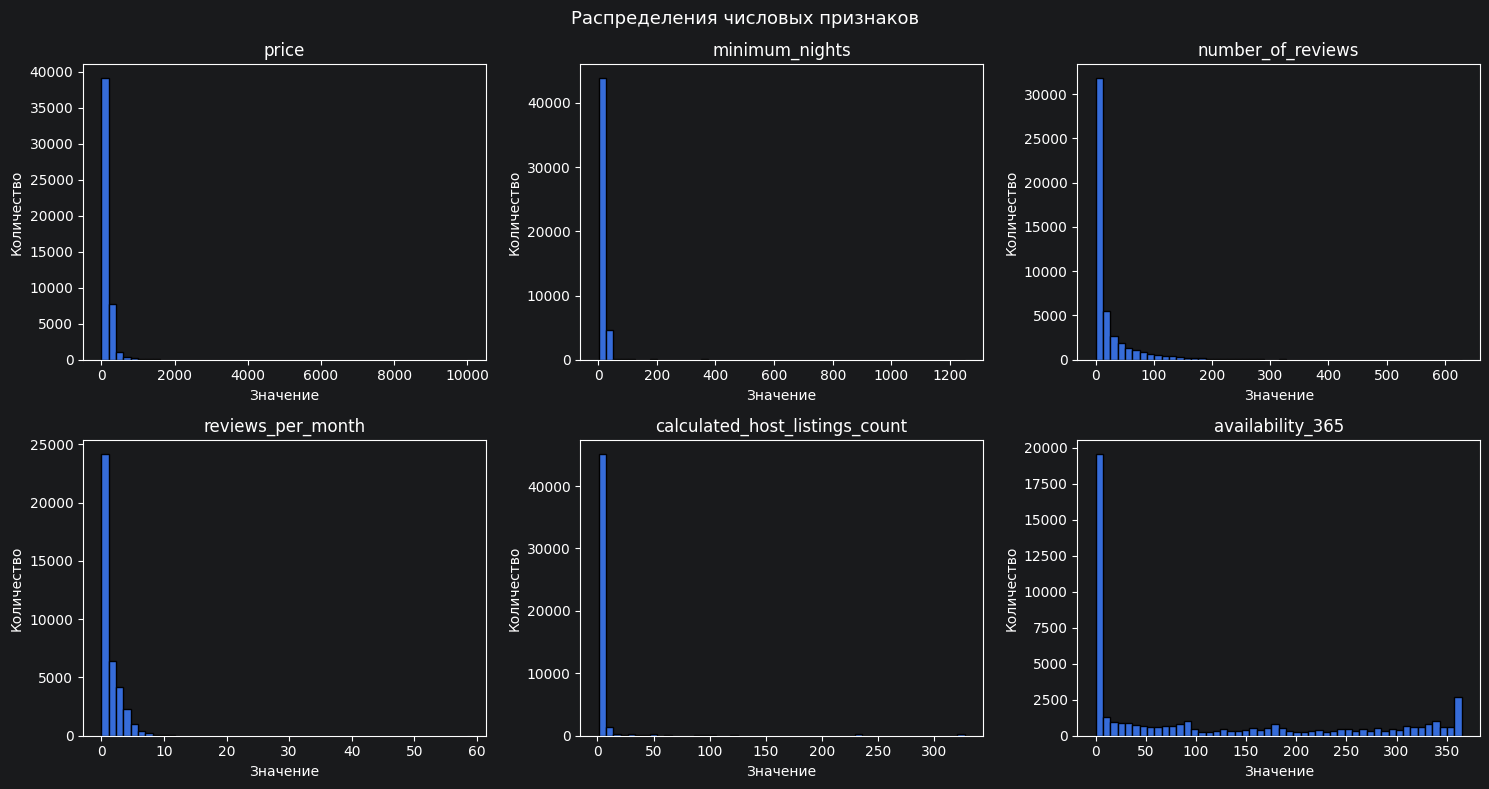

In [8]:
#Распределения числовых признаков
numeric_columns = ['price', 'minimum_nights', 'number_of_reviews',
                   'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, column_name in enumerate(numeric_columns):
    row = i // 3
    col = i % 3
    axes[row, col].hist(data[column_name].dropna(), bins=50, edgecolor='black')
    axes[row, col].set_title(column_name)
    axes[row, col].set_xlabel('Значение')
    axes[row, col].set_ylabel('Количество')

plt.suptitle('Распределения числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()

**Наблюдения по распределениям:**
- `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count` признаки скошены, большинство значений сосредоточено у небольших положительных чисел. Это указывает на необходимость логарифмирования + нормирования значений признаков.
- `availability_365` много объявлений либо почти недоступны (0 дней), либо доступны почти весь год (365 дней).


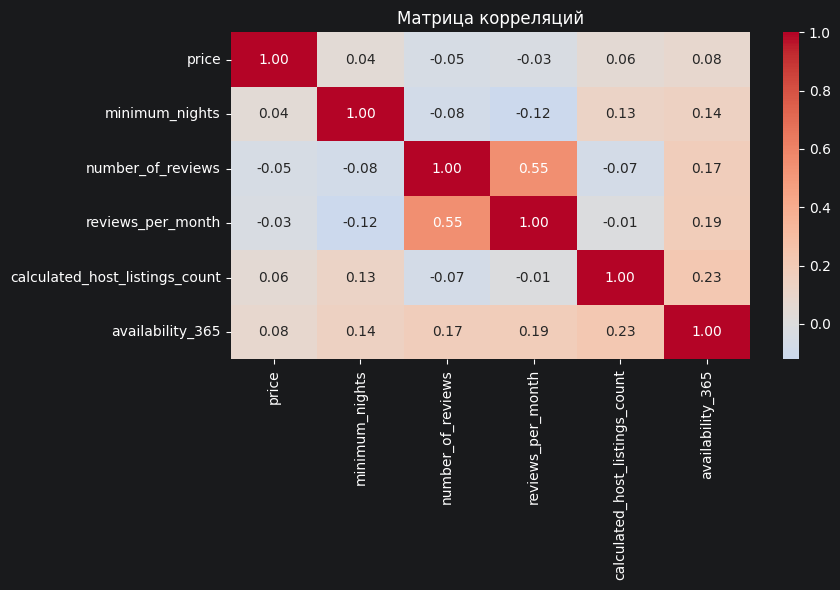

In [9]:
#Матрица попарных корреляций
correlation_matrix = data[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

**Наблюдения по корреляциям:**
- `price` и [`number_of_reviews`, `reviews_per_month`, `availability_365`] слабо коррелированы. Корреляция близка к нулю, значит, признаки не несут полезной информации для модели. Можнобудет удалить, чтобы облегчить модель.


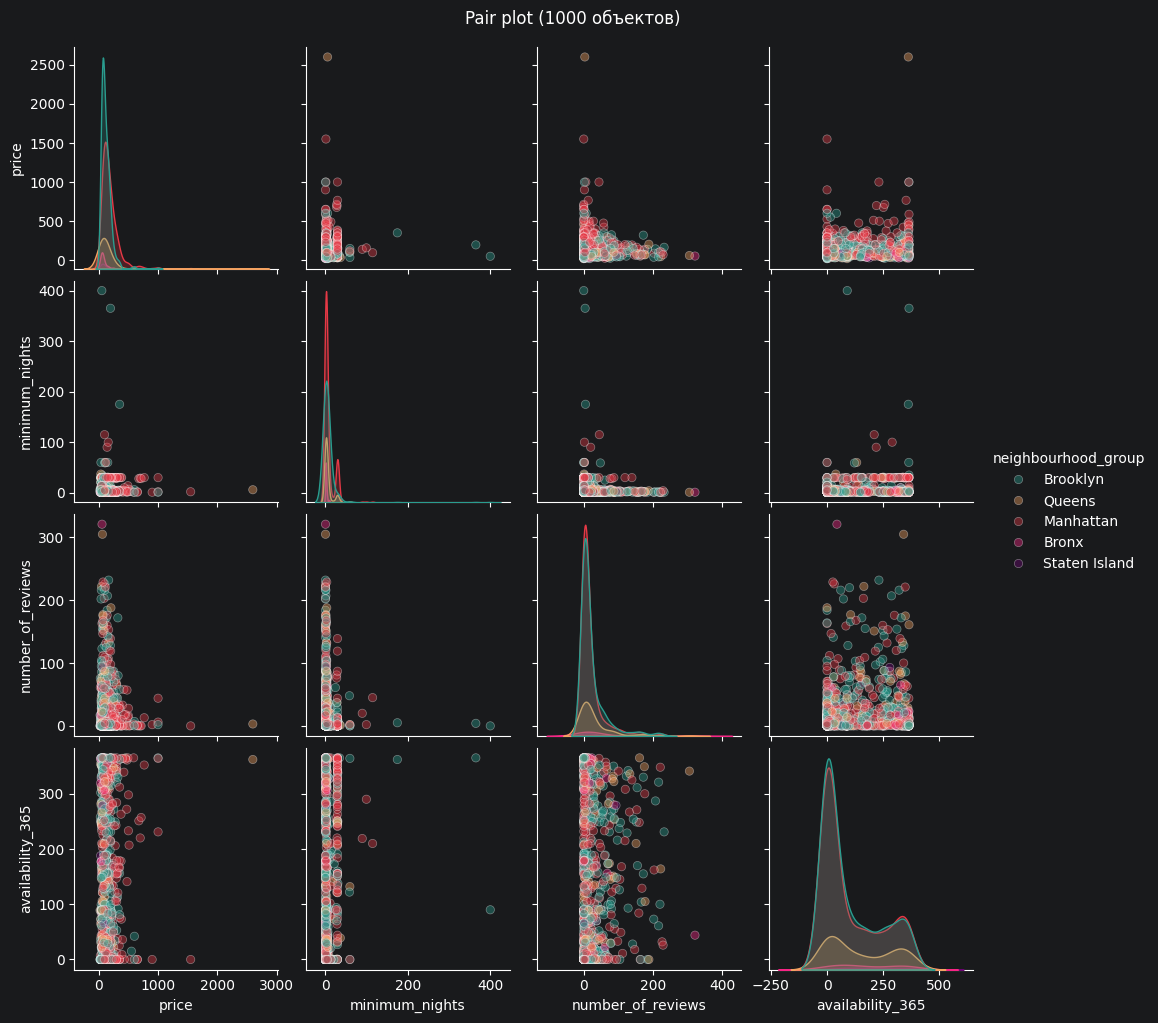

In [10]:
#Pair plot на подвыборке по округам из 1000 записей
pairplot_columns = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'neighbourhood_group']
data_sample = data[pairplot_columns].dropna().sample(1000, random_state=42)

neighbourhood_palette = {
    'Manhattan':    '#e63946',
    'Brooklyn':     '#2a9d8f',
    'Queens':       '#f4a261',
    'Bronx':        '#f72585',
    'Staten Island': '#6a0572'
}

sns.pairplot(data_sample, hue='neighbourhood_group', palette=neighbourhood_palette, plot_kws={'alpha': 0.4})
plt.suptitle('Pair plot (1000 объектов)', y=1.02)
plt.show()


так. Матрица корреляций показывает силу линейных связей численно. Pair plot дополняет её визуально: позволяет увидеть нелинейные зависимости, которые корреляция не улавливает, а также наглядно сравнить распределения признаков по округам. В Бруклине цена выше.

**Часть 2. Preprocessing & Feature Engineering**

In [11]:
#Посмотрим, есть ли записи с ошибочными значениями (меньше или равно 0) целевой переменной 'price'.
print('Размерность данных:', data.shape)
print('Размерность данных с ошибочными ценами(<= 0):', data[data['price'] <= 0].shape)

Размерность данных: (48895, 11)
Размерность данных с ошибочными ценами(<= 0): (11, 11)


In [12]:
#Нашли 11 записей. Удалим их
data = data[data['price'] > 0].copy()
print('Размерность после удаления ошибочных цен:', data.shape)


Размерность после удаления ошибочных цен: (48884, 11)


In [13]:
#Смотим макс хвост по цене, чтобы выбрать порог отсечения
#Смотрим на верхний хвост распределения цены и minimum_nights
percentiles = [95, 96, 97, 98, 99, 99.5, 100]

print('Перцентили price:')
for p in percentiles:
    percentile_value = data['price'].quantile(p / 100)
    print(f'  {p}%: ${percentile_value:.0f}')

print()
print('Перцентили minimum_nights:')
for p in percentiles:
    percentile_value = data['minimum_nights'].quantile(p / 100)
    print(f'  {p}%: {percentile_value:.0f} ночей')

print()
print('топ 20 по цене:')
top_prices = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'price']].sort_values('price', ascending=False).head(20)
print(top_prices.to_string(index=False))
print()
print('топ 20 по minimum_nights:')
top_nights = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'price']].sort_values('minimum_nights', ascending=False).head(20)
print(top_nights.to_string(index=False))

Перцентили price:
  95%: $355
  96%: $400
  97%: $450
  98%: $550
  99%: $799
  99.5%: $1000
  100%: $10000

Перцентили minimum_nights:
  95%: 30 ночей
  96%: 30 ночей
  97%: 30 ночей
  98%: 30 ночей
  99%: 45 ночей
  99.5%: 90 ночей
  100%: 1250 ночей

топ 20 по цене:
neighbourhood_group       room_type  minimum_nights  price
          Manhattan Entire home/apt              30  10000
           Brooklyn Entire home/apt               5  10000
             Queens    Private room             100  10000
          Manhattan    Private room              99   9999
          Manhattan Entire home/apt              30   9999
          Manhattan Entire home/apt               5   9999
          Manhattan Entire home/apt              30   8500
           Brooklyn Entire home/apt               1   8000
          Manhattan Entire home/apt               1   7703
          Manhattan Entire home/apt               1   7500
           Brooklyn    Private room               1   7500
          Manhattan En

In [14]:
#Цену не отсекаем: максимум $799 за ночь в Манхэттене, возможно реальные данные
#Фильтруем строки с аномальным minimum_nights. minimum_nights > 365 похоже на ошибку в данных, потому, что это уже долгосросчная аренда и цена за нее измеряется в других единицах ($ в месяц).
print('Строк с minimum_nights > 365:', (data['minimum_nights'] > 365).sum())

data = data[data['minimum_nights'] <= 365]
print('Размерность после удаления аномалий minimum_nights:', data.shape)

Строк с minimum_nights > 365: 14
Размерность после удаления аномалий minimum_nights: (48870, 11)


In [15]:
#Проверяем набблюдения корреляции `price` с признаками [`number_of_reviews`, `reviews_per_month`, `availability_365`]
print('Корреляция number_of_reviews с price:  ', round(data['number_of_reviews'].corr(data['price']), 4))
print('Корреляция reviews_per_month с price:  ', round(data['reviews_per_month'].corr(data['price']), 4))
print('Корреляция availability_365 с price:   ', round(data['availability_365'].corr(data['price']), 4))

Корреляция number_of_reviews с price:   -0.0479
Корреляция reviews_per_month с price:   -0.0306
Корреляция availability_365 с price:    0.0819


In [16]:
#Корреляция близка к нулю — признаки не несут полезной информации для модели.
#Удаляем все три, чтобы облегчить модель
data = data.drop(columns=['number_of_reviews', 'reviews_per_month', 'availability_365'])
print('Размерность после удаления признаков:', data.shape)

Размерность после удаления признаков: (48870, 8)


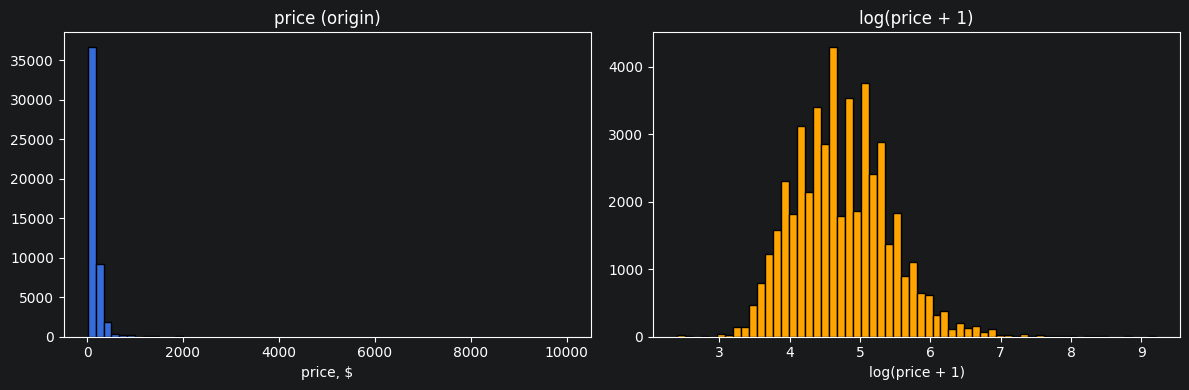

In [17]:
#Лог-преобразование целевой переменной
#Как мы уже видели на графиках Pair plot целевая переменная "price" имеет скошенное распределение — логарифм приближает его к нормальному.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['price'], bins=60, edgecolor='black')
axes[0].set_title('price (origin)')
axes[0].set_xlabel('price, $')

axes[1].hist(np.log1p(data['price']), bins=60, edgecolor='black', color='orange')
axes[1].set_title('log(price + 1)')
axes[1].set_xlabel('log(price + 1)')

plt.tight_layout()
plt.show()

#Используем log1p (= log(x+1)), чтобы корректно обработать нулевые значения
data['log_price'] = np.log1p(data['price'])

#Удаляем исходный столбец price, чтобы он не попал в признаки модели
data = data.drop(columns=['price'])

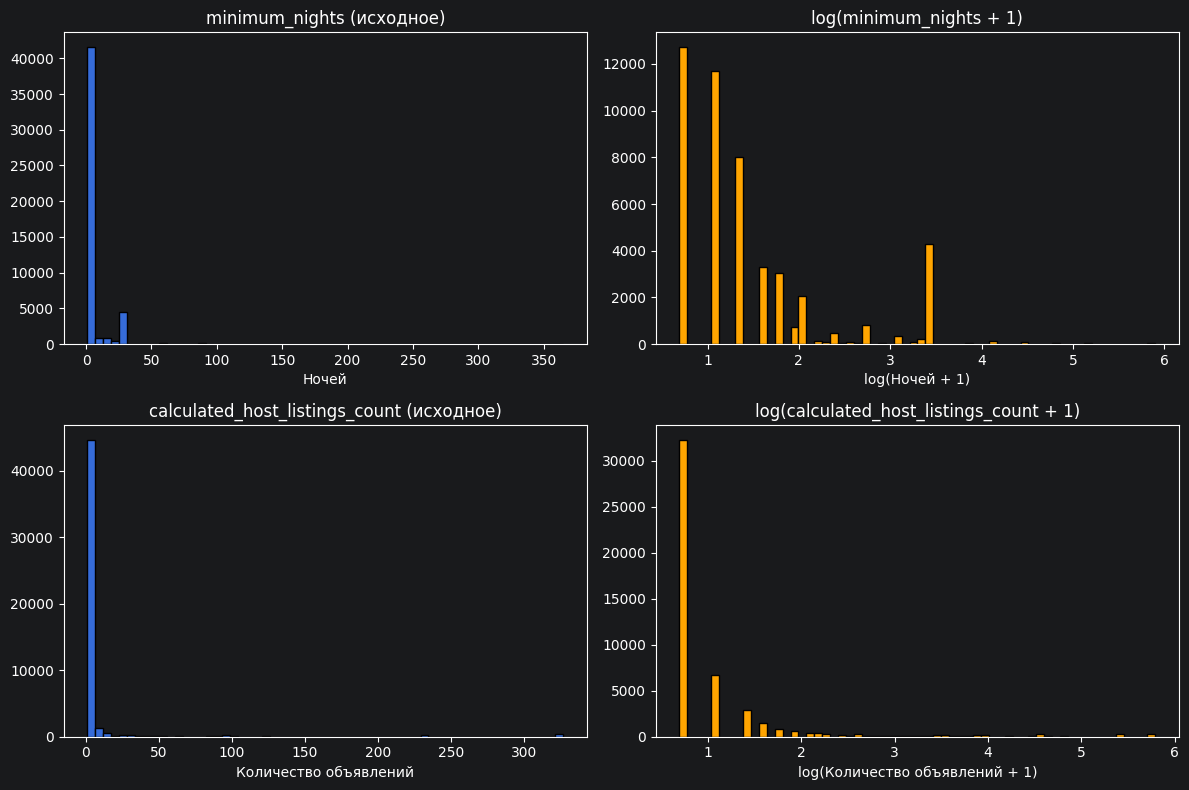

In [18]:
#Лог-преобразование другиз числовых числовых признаков
#minimum_nights и calculated_host_listings_count также имеют скошенное распределение
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(data['minimum_nights'], bins=60, edgecolor='black')
axes[0, 0].set_title('minimum_nights (исходное)')
axes[0, 0].set_xlabel('Ночей')

axes[0, 1].hist(np.log1p(data['minimum_nights']), bins=60, edgecolor='black', color='orange')
axes[0, 1].set_title('log(minimum_nights + 1)')
axes[0, 1].set_xlabel('log(Ночей + 1)')

axes[1, 0].hist(data['calculated_host_listings_count'], bins=60, edgecolor='black')
axes[1, 0].set_title('calculated_host_listings_count (исходное)')
axes[1, 0].set_xlabel('Количество объявлений')

axes[1, 1].hist(np.log1p(data['calculated_host_listings_count']), bins=60, edgecolor='black', color='orange')
axes[1, 1].set_title('log(calculated_host_listings_count + 1)')
axes[1, 1].set_xlabel('log(Количество объявлений + 1)')

plt.tight_layout()
plt.show()

#Используем log1p (= log(x+1)), чтобы корректно обработать нулевые значения
data['minimum_nights'] = np.log1p(data['minimum_nights'])
data['calculated_host_listings_count'] = np.log1p(data['calculated_host_listings_count'])


In [19]:
#После логарифмирования распределения minimum_nights и calculated_host_listings_count остаются скошенными, признаки дискретные и разреженные.
#Логарифм не помогает. Удаляем оба признака.
data = data.drop(columns=['minimum_nights', 'calculated_host_listings_count'])
print('Размерность после удаления признаков:', data.shape)

Размерность после удаления признаков: (48870, 6)


In [20]:
print(data.dtypes)

neighbourhood_group        str
neighbourhood              str
latitude               float64
longitude              float64
room_type                  str
log_price              float64
dtype: object


In [21]:
#Создаём новый признак: евклидово расстояние до центра Манхэттена
#Центр Манхэттена вычисляем как среднее координат объявлений из Manhattan
manhattan_data = data[data['neighbourhood_group'] == 'Manhattan']
manhattan_latitude = manhattan_data['latitude'].mean()
manhattan_longitude = manhattan_data['longitude'].mean()

print('Центр Манхэттена (среднее по объявлениям):')
print(f'  latitude:  {manhattan_latitude:.5f}')
print(f'  longitude: {manhattan_longitude:.5f}')

data['dist_to_manhattan'] = np.sqrt(
    (data['latitude'] - manhattan_latitude) ** 2 +
    (data['longitude'] - manhattan_longitude) ** 2
)

print()
print('Корреляция dist_to_manhattan с log_price:', round(data['dist_to_manhattan'].corr(data['log_price']), 3))
print('Корреляция latitude с log_price:          ', round(data['latitude'].corr(data['log_price']), 3))
print('Корреляция longitude с log_price:         ', round(data['longitude'].corr(data['log_price']), 3))

Центр Манхэттена (среднее по объявлениям):
  latitude:  40.76506
  longitude: -73.97460

Корреляция dist_to_manhattan с log_price: -0.358
Корреляция latitude с log_price:           0.079
Корреляция longitude с log_price:          -0.326


In [22]:
#Посмотрим на категориальные признаки
#Смотрим на количество уникальных значений категориальных признаков
print('Уникальных значений neighbourhood_group:', data['neighbourhood_group'].nunique())
print('Уникальных значений neighbourhood:      ', data['neighbourhood'].nunique())
print('Уникальных значений room_type:           ', data['room_type'].nunique())



Уникальных значений neighbourhood_group: 5
Уникальных значений neighbourhood:       221
Уникальных значений room_type:            3


In [23]:
#One Hot Encoding (OHE) для neighbourhood_group (5 значений) и room_type
#neighbourhood имеет 200 уникальных значений, много, удалять не хочется. оставим его для target encoding (по средней цене в этом районе) после разделения данных.
data = pd.get_dummies(data, columns=['neighbourhood_group', 'room_type'], drop_first=True)

print('Размерность после OHE:', data.shape)
print('Признаки:', list(data.columns))

Размерность после OHE: (48870, 11)
Признаки: ['neighbourhood', 'latitude', 'longitude', 'log_price', 'dist_to_manhattan', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']


In [24]:
#Переименовываем столбцы: заменяем пробелы на подчёркивания
new_columns = {}
for column in data.columns:
    new_columns[column] = column.replace(' ', '_')
data = data.rename(columns=new_columns)

print('Признаки:', list(data.columns))

Признаки: ['neighbourhood', 'latitude', 'longitude', 'log_price', 'dist_to_manhattan', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten_Island', 'room_type_Private_room', 'room_type_Shared_room']


**Часть 3. Моделирование**

In [25]:
#Разделяем признаки и целевую переменную
features = data.drop(columns=['log_price'])
target = data['log_price']

feature_columns = list(features.columns)

#Разбиение 70/30 — split делаем ДО target encoding, чтобы избежать утечки данных
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)
print('Обучающая выборка:', features_train.shape)
print('Тестовая выборка: ', features_test.shape)

#Target encoding для neighbourhood:
#считаем среднее log_price по каждому району только на train
neighbourhood_means = target_train.groupby(features_train['neighbourhood']).mean()
features_train['neighbourhood'] = features_train['neighbourhood'].map(neighbourhood_means)
features_test['neighbourhood'] = features_test['neighbourhood'].map(neighbourhood_means)

#Для районов, которых нет в train, заполняем средним по всему train
train_mean = target_train.mean()
features_train['neighbourhood'] = features_train['neighbourhood'].fillna(train_mean)
features_test['neighbourhood'] = features_test['neighbourhood'].fillna(train_mean)

print()
print('Пример target encoding neighbourhood (первые 5 значений train):')
print(features_train['neighbourhood'].head())

#RobustScaler для числовых признаков
numeric_features = ['latitude', 'longitude', 'dist_to_manhattan', 'neighbourhood']

scaler = RobustScaler()
features_train_scaled = features_train.copy()
features_test_scaled = features_test.copy()
features_train_scaled[numeric_features] = scaler.fit_transform(features_train[numeric_features])
features_test_scaled[numeric_features] = scaler.transform(features_test[numeric_features])

Обучающая выборка: (34209, 10)
Тестовая выборка:  (14661, 10)

Пример target encoding neighbourhood (первые 5 значений train):
12073    4.457875
5634     4.997133
32474    4.764547
32240    4.457875
15190    4.352562
Name: neighbourhood, dtype: float64


In [28]:
#Обучаем модели и считаем метрики
models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV':          RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    'LassoCV':          LassoCV(max_iter=5000, cv=5),
    'ElasticNetCV':     ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], max_iter=5000, cv=5)
}

metrics_results = {}

for model_name, model in models.items():
    model.fit(features_train_scaled, target_train)
    target_pred_log = model.predict(features_test_scaled)

    #Переводим обратно из log-пространства для MAE и RMSE
    target_pred_original = np.expm1(target_pred_log)
    target_test_original = np.expm1(target_test)

    r2   = r2_score(target_test, target_pred_log)
    mae  = mean_absolute_error(target_test_original, target_pred_original)
    rmse = np.sqrt(mean_squared_error(target_test_original, target_pred_original))

    metrics_results[model_name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f'{model_name:20s} | R²={r2:.4f} | MAE=${mae:.1f} | RMSE=${rmse:.1f}')

LinearRegression     | R²=0.5126 | MAE=$63.4 | RMSE=$254.0
RidgeCV              | R²=0.5126 | MAE=$63.4 | RMSE=$254.0
LassoCV              | R²=0.5126 | MAE=$63.4 | RMSE=$254.0
ElasticNetCV         | R²=0.5126 | MAE=$63.4 | RMSE=$254.0


метрики получились не очень...

### Итерация 2: Добавляем Interaction Features (room_type × neighbourhood_group)

In [29]:
#Загружаем данные заново — чистый датасет для новой итерации
data2 = pd.read_csv('data/AB_NYC_2019.csv')

#Те же шаги предобработки, что и в итерации 1
data2 = data2.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
data2 = data2[data2['price'] > 0].copy()
data2 = data2.drop(columns=['number_of_reviews', 'reviews_per_month', 'availability_365'])
data2 = data2[data2['minimum_nights'] <= 365]
data2 = data2.drop(columns=['minimum_nights', 'calculated_host_listings_count'])

data2['log_price'] = np.log1p(data2['price'])
data2 = data2.drop(columns=['price'])

manhattan_data2 = data2[data2['neighbourhood_group'] == 'Manhattan']
manhattan_lat2 = manhattan_data2['latitude'].mean()
manhattan_lon2 = manhattan_data2['longitude'].mean()
data2['dist_to_manhattan'] = np.sqrt(
    (data2['latitude'] - manhattan_lat2) ** 2 +
    (data2['longitude'] - manhattan_lon2) ** 2
)

print('Размерность данных:', data2.shape)

Размерность данных: (48870, 7)


In [30]:
#Новый признак: interaction room_type × neighbourhood_group
#Модель видела room_type и neighbourhood_group по отдельности,
#но не знала, что "Entire home" в Манхэттене — совершенно другая история, чем в Бронксе
data2['room_neighbourhood'] = data2['room_type'] + '_' + data2['neighbourhood_group']
print('Уникальных значений room_neighbourhood:', data2['room_neighbourhood'].nunique())
print()
print(data2['room_neighbourhood'].value_counts().to_string())

Уникальных значений room_neighbourhood: 15

room_neighbourhood
Entire home/apt_Manhattan        13193
Private room_Brooklyn            10122
Entire home/apt_Brooklyn          9556
Private room_Manhattan            7982
Private room_Queens               3372
Entire home/apt_Queens            2094
Private room_Bronx                 651
Shared room_Manhattan              479
Shared room_Brooklyn               411
Entire home/apt_Bronx              379
Shared room_Queens                 198
Private room_Staten Island         188
Entire home/apt_Staten Island      176
Shared room_Bronx                   60
Shared room_Staten Island            9


In [31]:
#OHE для neighbourhood_group, room_type и interaction-признака
data2_model = pd.get_dummies(data2, columns=['neighbourhood_group', 'room_type', 'room_neighbourhood'], drop_first=True)

new_columns2 = {}
for column in data2_model.columns:
    new_columns2[column] = column.replace(' ', '_')
data2_model = data2_model.rename(columns=new_columns2)

print('Размерность после OHE:', data2_model.shape)
print('Признаки:', list(data2_model.columns))

Размерность после OHE: (48870, 25)
Признаки: ['neighbourhood', 'latitude', 'longitude', 'log_price', 'dist_to_manhattan', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten_Island', 'room_type_Private_room', 'room_type_Shared_room', 'room_neighbourhood_Entire_home/apt_Brooklyn', 'room_neighbourhood_Entire_home/apt_Manhattan', 'room_neighbourhood_Entire_home/apt_Queens', 'room_neighbourhood_Entire_home/apt_Staten_Island', 'room_neighbourhood_Private_room_Bronx', 'room_neighbourhood_Private_room_Brooklyn', 'room_neighbourhood_Private_room_Manhattan', 'room_neighbourhood_Private_room_Queens', 'room_neighbourhood_Private_room_Staten_Island', 'room_neighbourhood_Shared_room_Bronx', 'room_neighbourhood_Shared_room_Brooklyn', 'room_neighbourhood_Shared_room_Manhattan', 'room_neighbourhood_Shared_room_Queens', 'room_neighbourhood_Shared_room_Staten_Island']


In [33]:
#Train/test split, target encoding для neighbourhood, масштабирование
features2 = data2_model.drop(columns=['log_price'])
target2 = data2_model['log_price']

feature_columns2 = list(features2.columns)

features2_train, features2_test, target2_train, target2_test = train_test_split(
    features2, target2, test_size=0.3, random_state=42
)
print('Обучающая выборка:', features2_train.shape)
print('Тестовая выборка: ', features2_test.shape)

#Target encoding для neighbourhood — только на train
neighbourhood_means2 = target2_train.groupby(features2_train['neighbourhood']).mean()
features2_train['neighbourhood'] = features2_train['neighbourhood'].map(neighbourhood_means2)
features2_test['neighbourhood'] = features2_test['neighbourhood'].map(neighbourhood_means2)

train_mean2 = target2_train.mean()
features2_train['neighbourhood'] = features2_train['neighbourhood'].fillna(train_mean2)
features2_test['neighbourhood'] = features2_test['neighbourhood'].fillna(train_mean2)

numeric_features2 = ['latitude', 'longitude', 'dist_to_manhattan', 'neighbourhood']

scaler2 = RobustScaler()
features2_train_scaled = features2_train.copy()
features2_test_scaled = features2_test.copy()
features2_train_scaled[numeric_features2] = scaler2.fit_transform(features2_train[numeric_features2])
features2_test_scaled[numeric_features2] = scaler2.transform(features2_test[numeric_features2])

Обучающая выборка: (34209, 24)
Тестовая выборка:  (14661, 24)


In [34]:
#Обучаем модели и считаем метрики — итерация 2
models2 = {
    'LinearRegression': LinearRegression(),
    'RidgeCV':          RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    'LassoCV':          LassoCV(max_iter=5000, cv=5),
    'ElasticNetCV':     ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], max_iter=5000, cv=5)
}

metrics_results2 = {}

for model_name, model in models2.items():
    model.fit(features2_train_scaled, target2_train)
    target2_pred_log = model.predict(features2_test_scaled)

    target2_pred_original = np.expm1(target2_pred_log)
    target2_test_original = np.expm1(target2_test)

    r2   = r2_score(target2_test, target2_pred_log)
    mae  = mean_absolute_error(target2_test_original, target2_pred_original)
    rmse = np.sqrt(mean_squared_error(target2_test_original, target2_pred_original))

    metrics_results2[model_name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f'{model_name:20s} | R²={r2:.4f} | MAE=${mae:.1f} | RMSE=${rmse:.1f}')

print()
print('--- Сравнение с итерацией 1 (без interaction) ---')
print(f'{"Модель":20s} | {"R² iter1":>10} | {"R² iter2":>10} | {"Δ R²":>8}')
baseline_r2 = 0.5126
for model_name in metrics_results2:
    r2_iter2 = metrics_results2[model_name]['R2']
    print(f'{model_name:20s} | {baseline_r2:>10.4f} | {r2_iter2:>10.4f} | {r2_iter2 - baseline_r2:>+8.4f}')

LinearRegression     | R²=0.5138 | MAE=$63.4 | RMSE=$254.0
RidgeCV              | R²=0.5138 | MAE=$63.4 | RMSE=$254.0
LassoCV              | R²=0.5140 | MAE=$63.4 | RMSE=$254.0
ElasticNetCV         | R²=0.5140 | MAE=$63.4 | RMSE=$254.0

--- Сравнение с итерацией 1 (без interaction) ---
Модель               |   R² iter1 |   R² iter2 |     Δ R²
LinearRegression     |     0.5126 |     0.5138 |  +0.0012
RidgeCV              |     0.5126 |     0.5138 |  +0.0012
LassoCV              |     0.5126 |     0.5140 |  +0.0014
ElasticNetCV         |     0.5126 |     0.5140 |  +0.0014


стало не намного лучше.


### Итерация 3: Добавляем Polynomial Features (degree=2) для latitude, longitude, dist_to_manhattan

In [35]:
from sklearn.preprocessing import PolynomialFeatures

#Загружаем данные заново и применяем те же шаги предобработки
data3 = pd.read_csv('data/AB_NYC_2019.csv')
data3 = data3.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
data3 = data3[data3['price'] > 0].copy()
data3 = data3.drop(columns=['number_of_reviews', 'reviews_per_month', 'availability_365'])
data3 = data3[data3['minimum_nights'] <= 365]
data3 = data3.drop(columns=['minimum_nights', 'calculated_host_listings_count'])

data3['log_price'] = np.log1p(data3['price'])
data3 = data3.drop(columns=['price'])

manhattan_data3 = data3[data3['neighbourhood_group'] == 'Manhattan']
manhattan_lat3 = manhattan_data3['latitude'].mean()
manhattan_lon3 = manhattan_data3['longitude'].mean()
data3['dist_to_manhattan'] = np.sqrt(
    (data3['latitude'] - manhattan_lat3) ** 2 +
    (data3['longitude'] - manhattan_lon3) ** 2
)

#OHE
data3_model = pd.get_dummies(data3, columns=['neighbourhood_group', 'room_type'], drop_first=True)
new_columns3 = {}
for column in data3_model.columns:
    new_columns3[column] = column.replace(' ', '_')
data3_model = data3_model.rename(columns=new_columns3)

#Split
features3 = data3_model.drop(columns=['log_price'])
target3 = data3_model['log_price']

features3_train, features3_test, target3_train, target3_test = train_test_split(
    features3, target3, test_size=0.3, random_state=42
)

#Target encoding для neighbourhood
neighbourhood_means3 = target3_train.groupby(features3_train['neighbourhood']).mean()
features3_train['neighbourhood'] = features3_train['neighbourhood'].map(neighbourhood_means3)
features3_test['neighbourhood'] = features3_test['neighbourhood'].map(neighbourhood_means3)
train_mean3 = target3_train.mean()
features3_train['neighbourhood'] = features3_train['neighbourhood'].fillna(train_mean3)
features3_test['neighbourhood'] = features3_test['neighbourhood'].fillna(train_mean3)

#Масштабирование числовых признаков
numeric_features3 = ['latitude', 'longitude', 'dist_to_manhattan', 'neighbourhood']
scaler3 = RobustScaler()
features3_train_scaled = features3_train.copy()
features3_test_scaled = features3_test.copy()
features3_train_scaled[numeric_features3] = scaler3.fit_transform(features3_train[numeric_features3])
features3_test_scaled[numeric_features3] = scaler3.transform(features3_test[numeric_features3])

print('Размерность до полиномиальных признаков:', features3_train_scaled.shape)

Размерность до полиномиальных признаков: (34209, 10)


In [36]:
#Добавляем полиномиальные признаки degree=2 для геопризнаков
#Это позволяет линейной модели уловить нелинейную зависимость цены от координат:
#lat², lon², dist², lat×lon, lat×dist, lon×dist
poly_cols = ['latitude', 'longitude', 'dist_to_manhattan']

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_train = poly.fit_transform(features3_train_scaled[poly_cols])
poly_test = poly.transform(features3_test_scaled[poly_cols])

poly_feature_names = poly.get_feature_names_out(poly_cols)

poly_train_df = pd.DataFrame(poly_train, columns=poly_feature_names, index=features3_train_scaled.index)
poly_test_df = pd.DataFrame(poly_test, columns=poly_feature_names, index=features3_test_scaled.index)

#Убираем исходные 3 столбца и добавляем полиномиальные (они уже включают исходные степени 1)
non_poly_cols = []
for col in features3_train_scaled.columns:
    if col not in poly_cols:
        non_poly_cols.append(col)

features3_train_poly = pd.concat([features3_train_scaled[non_poly_cols], poly_train_df], axis=1)
features3_test_poly = pd.concat([features3_test_scaled[non_poly_cols], poly_test_df], axis=1)

feature_columns3 = list(features3_train_poly.columns)
print('Размерность после полиномиальных признаков:', features3_train_poly.shape)
print('Новые признаки:', list(poly_feature_names))

Размерность после полиномиальных признаков: (34209, 16)
Новые признаки: ['latitude', 'longitude', 'dist_to_manhattan', 'latitude^2', 'latitude longitude', 'latitude dist_to_manhattan', 'longitude^2', 'longitude dist_to_manhattan', 'dist_to_manhattan^2']


In [37]:
#Обучаем модели и считаем метрики — итерация 3
models3 = {
    'LinearRegression': LinearRegression(),
    'RidgeCV':          RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    'LassoCV':          LassoCV(max_iter=5000, cv=5),
    'ElasticNetCV':     ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], max_iter=5000, cv=5)
}

metrics_results3 = {}

for model_name, model in models3.items():
    model.fit(features3_train_poly, target3_train)
    target3_pred_log = model.predict(features3_test_poly)

    target3_pred_original = np.expm1(target3_pred_log)
    target3_test_original = np.expm1(target3_test)

    r2   = r2_score(target3_test, target3_pred_log)
    mae  = mean_absolute_error(target3_test_original, target3_pred_original)
    rmse = np.sqrt(mean_squared_error(target3_test_original, target3_pred_original))

    metrics_results3[model_name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f'{model_name:20s} | R²={r2:.4f} | MAE=${mae:.1f} | RMSE=${rmse:.1f}')

print()
print('--- Сравнение итераций ---')
print(f'{"Модель":20s} | {"R² iter1":>10} | {"R² iter2":>10} | {"R² iter3":>10}')
for model_name in metrics_results3:
    r2_3 = metrics_results3[model_name]['R2']
    r2_2 = metrics_results2[model_name]['R2']
    print(f'{model_name:20s} | {0.5126:>10.4f} | {r2_2:>10.4f} | {r2_3:>10.4f}')

LinearRegression     | R²=0.5146 | MAE=$63.3 | RMSE=$254.0
RidgeCV              | R²=0.5146 | MAE=$63.3 | RMSE=$254.0
LassoCV              | R²=0.5146 | MAE=$63.3 | RMSE=$254.0
ElasticNetCV         | R²=0.5146 | MAE=$63.3 | RMSE=$254.0

--- Сравнение итераций ---
Модель               |   R² iter1 |   R² iter2 |   R² iter3
LinearRegression     |     0.5126 |     0.5138 |     0.5146
RidgeCV              |     0.5126 |     0.5138 |     0.5146
LassoCV              |     0.5126 |     0.5140 |     0.5146
ElasticNetCV         |     0.5126 |     0.5140 |     0.5146


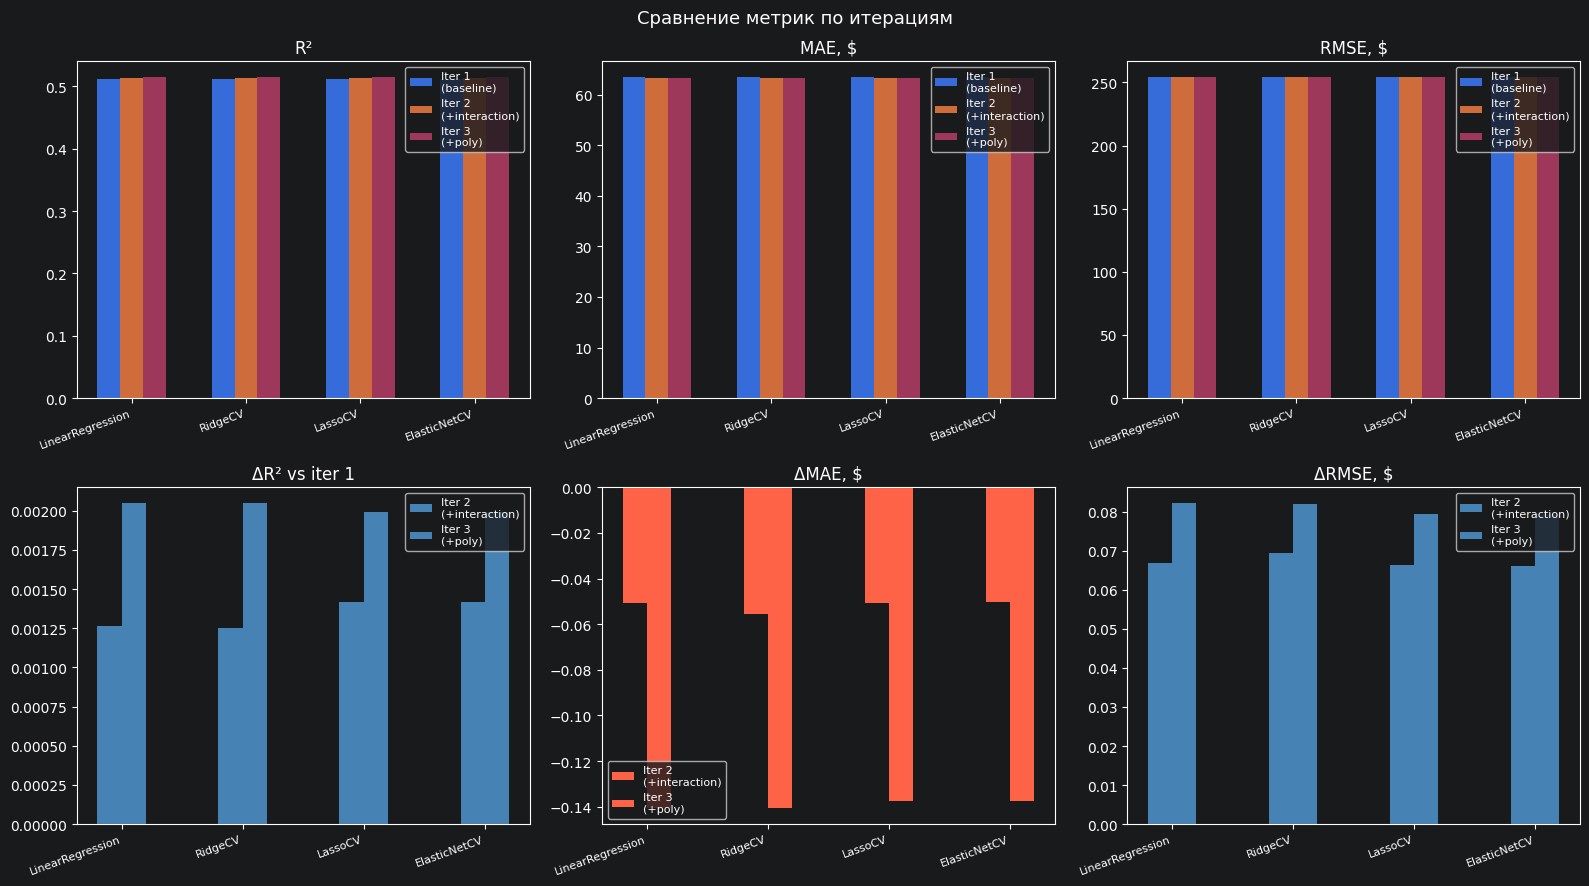

In [39]:
#Визуализация сравнения метрик по трём итерациям
#Верхний ряд: абсолютные значения; нижний ряд: изменение относительно итерации 1
iteration_labels = ['Iter 1\n(baseline)', 'Iter 2\n(+interaction)', 'Iter 3\n(+poly)']
model_names_list = ['LinearRegression', 'RidgeCV', 'LassoCV', 'ElasticNetCV']
metric_keys = ['R2', 'MAE', 'RMSE']
metric_titles = ['R²', 'MAE, $', 'RMSE, $']
delta_titles = ['ΔR² vs iter 1', 'ΔMAE, $', 'ΔRMSE, $']

all_results = [metrics_results, metrics_results2, metrics_results3]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

bar_width = 0.2
x_positions = list(range(len(model_names_list)))

for metric_idx, (metric_key, metric_title, delta_title) in enumerate(zip(metric_keys, metric_titles, delta_titles)):

    #Верхний ряд — абсолютные значения
    ax_abs = axes[0, metric_idx]
    for iter_idx, iter_results in enumerate(all_results):
        values = []
        for model_name in model_names_list:
            values.append(iter_results[model_name][metric_key])
        offsets = [x + iter_idx * bar_width for x in x_positions]
        ax_abs.bar(offsets, values, width=bar_width, label=iteration_labels[iter_idx])
    ax_abs.set_title(metric_title, fontsize=12)
    ax_abs.set_xticks([x + bar_width for x in x_positions])
    ax_abs.set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=8)
    ax_abs.legend(fontsize=8)

    #Нижний ряд — дельта относительно итерации 1 (baseline)
    ax_delta = axes[1, metric_idx]
    baseline_values = {}
    for model_name in model_names_list:
        baseline_values[model_name] = metrics_results[model_name][metric_key]

    for iter_idx, iter_results in enumerate(all_results[1:], start=1):
        deltas = []
        for model_name in model_names_list:
            deltas.append(iter_results[model_name][metric_key] - baseline_values[model_name])
        offsets = [(x + (iter_idx - 1) * bar_width) for x in x_positions]
        colors = ['steelblue' if d >= 0 else 'tomato' for d in deltas]
        ax_delta.bar(offsets, deltas, width=bar_width, color=colors, label=iteration_labels[iter_idx])

    ax_delta.axhline(0, color='black', linewidth=0.8)
    ax_delta.set_title(delta_title, fontsize=12)
    ax_delta.set_xticks([x + bar_width * 0.5 for x in x_positions])
    ax_delta.set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=8)
    ax_delta.legend(fontsize=8)

plt.suptitle('Сравнение метрик по итерациям', fontsize=13)
plt.tight_layout()
plt.show()

## Итоги

### Результаты по итерациям

| Итерация | Изменение | R² | MAE | RMSE |
|---|---|---|---|---|
| 1 — baseline | OHE + target encoding + dist_to_manhattan + RobustScaler | 0.5126 | $63.4 | $254.0 |
| 2 — +interaction | Добавлен признак `room_type × neighbourhood_group` | 0.5140 | $63.4 | $254.0 |
| 3 — +poly | Добавлены полиномиальные признаки degree=2 для координат | 0.5146 | $63.3 | $254.0 |

### Выводы

- **Все четыре модели (LinearRegression, RidgeCV, LassoCV, ElasticNetCV) дают практически одинаковый результат** во всех итерациях. Регуляризация не помогла - данные хорошо обусловлены, мультиколлинеарности нет, признаков немного.

- **R²≈0.51 - похоже, что это максимум для этих линейных моделей на этом датасете.** Цена на Airbnb нелинейно зависит от признаков: один и тот же тип жилья в одном районе может стоить в 5 раз дороже другого. Линейная регрессия принципиально не улавливает такую структуру.

- **RMSE=$254  при  MAE=$63**. Такой большой разрыв говорит о том, что на большинстве объектов модель ошибается на ~$63, но на дорогих квартирах промахивается сильно. Feature engineering без обрезки выбросов этот разрыв не устраняет. А если обрежем выбросы (высокие цены), то модель не сможет предсказывать цены на дорогую недвижимость.

- **Самый полезный шаг** - log-преобразование целевой переменной `price` и target encoding для `neighbourhood`. Всё остальное (interaction features, poly features) дало прирост R² менее 0.002.

- Для существенного улучшения качества потребовались бы нелинейные модели, например, Random Forest или градиентный бустинг.

### Анализ разброса цен внутри районов

Если даже внутри одного района цены сильно различаются, значит, признаки локации не объясняют цену, и ошибка модели неизбежна.

In [40]:
#Загружаем оригинальные данные с ценой для анализа разброса
data_prices = pd.read_csv('data/AB_NYC_2019.csv')
data_prices = data_prices[data_prices['price'] > 0].copy()

#Статистика по каждому сочетанию neighbourhood_group + neighbourhood
neighbourhood_stats = data_prices.groupby(['neighbourhood_group', 'neighbourhood'])['price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).reset_index()

#Коэффициент вариации: std/mean — показывает разброс относительно среднего
neighbourhood_stats['cv'] = neighbourhood_stats['std'] / neighbourhood_stats['mean']

#Оставляем только районы с достаточным количеством объявлений
neighbourhood_stats = neighbourhood_stats[neighbourhood_stats['count'] >= 30]

print(f'Районов с ≥30 объявлений: {len(neighbourhood_stats)}')
print()
print('Медианный коэффициент вариации по округам:')
cv_by_group = neighbourhood_stats.groupby('neighbourhood_group')['cv'].median().sort_values(ascending=False)
print(cv_by_group.round(2).to_string())
print()
print('Топ-10 районов с наибольшим разбросом цен (CV):')
top_cv = neighbourhood_stats.sort_values('cv', ascending=False).head(10)
print(top_cv[['neighbourhood_group', 'neighbourhood', 'count', 'mean', 'std', 'min', 'max', 'cv']].round(1).to_string(index=False))

Районов с ≥30 объявлений: 115

Медианный коэффициент вариации по округам:
neighbourhood_group
Manhattan        1.06
Brooklyn         0.89
Staten Island    0.88
Queens           0.72
Bronx            0.68

Топ-10 районов с наибольшим разбросом цен (CV):
neighbourhood_group     neighbourhood  count  mean   std  min   max  cv
           Brooklyn     Cypress Hills    135 128.9 434.9   19  5000 3.4
           Brooklyn     East Flatbush    500 104.2 338.1   15  7500 3.2
             Queens           Astoria    900 117.2 349.9   25 10000 3.0
           Brooklyn         Bay Ridge    141 144.4 383.2   18  4200 2.7
          Manhattan Battery Park City     70 367.6 974.7   55  7500 2.7
           Brooklyn      Clinton Hill    572 181.9 475.4   35  8000 2.6
             Queens           Bayside     39 157.9 407.6   30  2600 2.6
          Manhattan   Lower East Side    911 186.3 478.7   29  9999 2.6
           Brooklyn    Brighton Beach     75 131.9 338.7   30  3000 2.6
          Manhattan       E

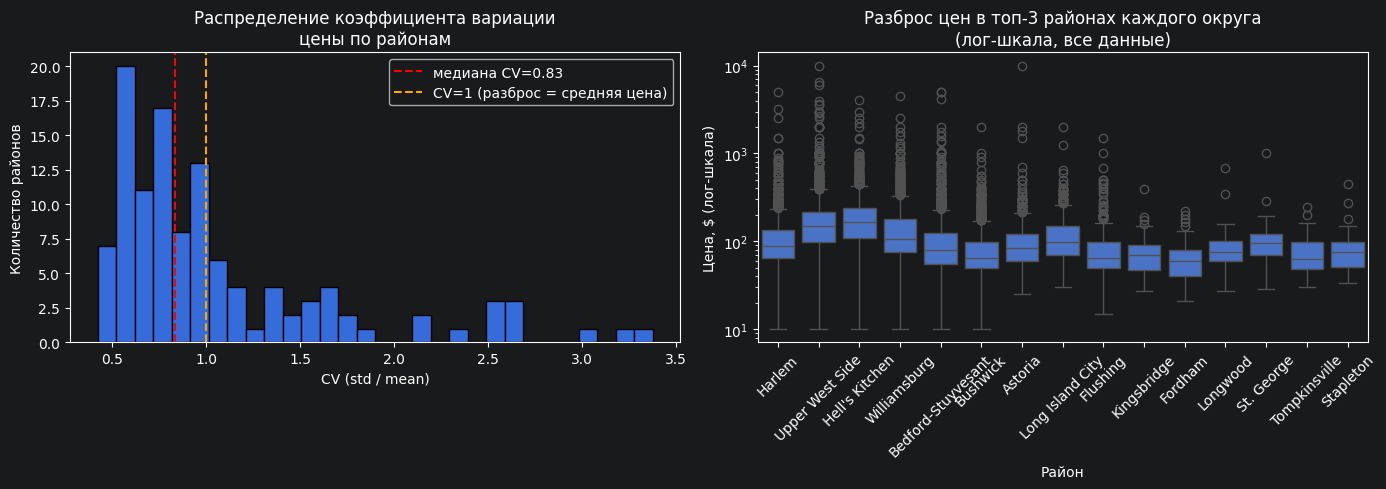

In [42]:
#Визуализация: распределение коэффициента вариации по округам
#CV > 1 означает, что разброс цен превышает среднюю цену в районе

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Левый: гистограмма CV по всем районам
axes[0].hist(neighbourhood_stats['cv'], bins=30, edgecolor='black')
axes[0].axvline(neighbourhood_stats['cv'].median(), color='red', linestyle='--', label=f'медиана CV={neighbourhood_stats["cv"].median():.2f}')
axes[0].axvline(1.0, color='orange', linestyle='--', label='CV=1 (разброс = средняя цена)')
axes[0].set_title('Распределение коэффициента вариации\nцены по районам')
axes[0].set_xlabel('CV (std / mean)')
axes[0].set_ylabel('Количество районов')
axes[0].legend()

#Правый: box plot цен для топ-3 районов каждого округа, лог-шкала, все точки видны
borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
top_neighbourhoods = []
for borough in borough_order:
    borough_data = data_prices[data_prices['neighbourhood_group'] == borough]
    top_in_borough = borough_data['neighbourhood'].value_counts().head(3).index.tolist()
    top_neighbourhoods.extend(top_in_borough)

plot_data = data_prices[data_prices['neighbourhood'].isin(top_neighbourhoods)].copy()

neighbourhood_order = []
for borough in borough_order:
    for n in top_neighbourhoods:
        if n in data_prices[data_prices['neighbourhood_group'] == borough]['neighbourhood'].values:
            if n not in neighbourhood_order:
                neighbourhood_order.append(n)

sns.boxplot(
    data=plot_data,
    x='neighbourhood',
    y='price',
    order=neighbourhood_order,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Разброс цен в топ-3 районах каждого округа\n(лог-шкала, все данные)')
axes[1].set_xlabel('Район')
axes[1].set_ylabel('Цена, $ (лог-шкала)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Заключение
Как мы можем видеть на графиках, достаточно большой разброс цен внутри каждого сочетания (neighbourhood_group + neighbourhood).

MAE = $\$63$ на среднем ценнике $\$100-150$ за ночь = это очень большая ошибка в 40-60%.

Можно предположить, что проблема не только в моделях. В датасете просто нет признаков, которые объясняют цену. У нас есть координаты, тип комнаты и район — но цена на Airbnb может определяется еще и тем, чего в данных нет:
  - площадь обьекта аренды
  - качество ремонта
  - наличие Wi-Fi, кухни, стиралки
  - вид из окна
  - сезонность
  - возможность размещения с животными
  - лифт
  - и т.д. и т.п.

Два объявления в одном районе (возможно даже в одном доме) с одинаковым room_type могут стоить $\$80$ и $\$300$, и ни одна модель не объяснит эту разницу без дополнительных данных.

  Так что $R²=0.51$ и $MAE=\$63$ - это не провал модели, это потолок датасета.